# Task 1 — Data Exploration and Schema Understanding
**Ethiopia Financial Inclusion Forecast**

This notebook covers: loading the starter dataset, understanding
the unified schema, and exploring what is (and isn't) covered before we enrich it.

Enrichment itself (new observations/events/impact_links, with full source documentation) is
carried out in `02.ipynb` and logged in `data_enrichment_log.md`.


In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np

from data_loader import (
    load_unified_data, load_reference_codes, validate_against_reference,
    get_observations, get_events, get_impact_links, events_with_impacts
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

DATA_PATH = '../data/raw/ethiopia_fi_unified_data.csv'
REF_PATH = '../data/raw/reference_codes.csv'

df = load_unified_data(DATA_PATH)
ref = load_reference_codes(REF_PATH)

print(f"Unified dataset: {df.shape[0]} records, {df.shape[1]} columns")
print(f"Reference codes: {ref.shape[0]} rows")

Unified dataset: 57 records, 35 columns
Reference codes: 71 rows


## 1. Schema Understanding

The dataset uses a **unified schema**: every record — whether it's a survey result, a
product launch, or a modeled relationship — lives in the same table with the same 35
columns. The `record_type` column tells us how to interpret each row:

| `record_type` | What it represents | Count |
|---|---|---|
| `observation` | A measured value from a survey, operator report, or regulator | 30 |
| `event` | A policy, product launch, market entry, or milestone | 10 |
| `impact_link` | A modeled effect of one event on one indicator | 14 |
| `target` | An official policy goal (e.g. NFIS-II) | 3 |

**The critical design choice** (see `data/raw/README.md`) is that `event` records are
*never* pre-assigned a `pillar`. Telebirr's launch, for instance, plausibly affects both
Access (more accounts) and Usage (more transactions) — hard-coding it to one pillar would
bias any model built on top of it. Instead, each event fans out into one or more
`impact_link` rows, and *those* carry the pillar of the indicator they affect, linked back
to the parent event through `parent_id -> record_id`.

In [2]:
print(df['record_type'].value_counts())
print()
print("Schema compliance check (values outside reference_codes.csv):")
issues = validate_against_reference(df, ref)
print(issues if issues else "None — every categorical value in the dataset matches an allowed code.")

record_type
observation    30
impact_link    14
event          10
target          3
Name: count, dtype: int64

Schema compliance check (values outside reference_codes.csv):
None — every categorical value in the dataset matches an allowed code.


In [3]:
# Confirm the no-pre-assignment rule holds in the starter data
events = get_events(df)
print("Events with a non-empty pillar (should be 0):", events['pillar'].notna().sum())
events[['record_id','category','indicator','observation_date']]

Events with a non-empty pillar (should be 0): 0


,record_id,category,indicator,observation_date
33,EVT_0001,product_launch,Telebirr Launch,2021-05-17
34,EVT_0002,market_entry,Safaricom Ethiopia Commercial Launch,2022-08-01
35,EVT_0003,product_launch,M-Pesa Ethiopia Launch,2023-08-01
36,EVT_0004,infrastructure,Fayda Digital ID Program Rollout,2024-01-01
37,EVT_0005,policy,Foreign Exchange Liberalization,2024-07-29
38,EVT_0006,milestone,P2P Transaction Count Surpasses ATM,2024-10-01
39,EVT_0007,partnership,M-Pesa EthSwitch Integration,2025-10-27
40,EVT_0008,infrastructure,EthioPay Instant Payment System Launch,2025-12-18
41,EVT_0009,policy,NFIS-II Strategy Launch,2021-09-01
42,EVT_0010,pricing,Safaricom Ethiopia Price Increase,2025-12-15


## 2. How `impact_link` connects events to indicators

Each `impact_link` row references its parent event via `parent_id`, and specifies the
affected indicator, the estimated direction/magnitude/lag, and the evidence basis. Joining
on `parent_id -> record_id` lets us ask "what does this event affect?" without ever having
baked that answer into the event record itself.

In [4]:
ei = events_with_impacts(df)
view_cols = ['event_indicator', 'event_category', 'event_observation_date',
             'impact_related_indicator', 'impact_pillar', 'impact_relationship_type',
             'impact_impact_direction', 'impact_impact_magnitude', 'impact_lag_months',
             'impact_evidence_basis', 'impact_comparable_country']
ei[view_cols].sort_values('event_observation_date')

,event_indicator,event_category,event_observation_date,impact_related_indicator,impact_pillar,impact_relationship_type,impact_impact_direction,impact_impact_magnitude,impact_lag_months,impact_evidence_basis,impact_comparable_country
0,Telebirr Launch,product_launch,2021-05-17,ACC_OWNERSHIP,ACCESS,direct,increase,high,12.0,literature,Kenya
1,Telebirr Launch,product_launch,2021-05-17,USG_TELEBIRR_USERS,USAGE,direct,increase,high,3.0,empirical,NaN
2,Telebirr Launch,product_launch,2021-05-17,USG_P2P_COUNT,USAGE,direct,increase,high,6.0,empirical,NaN
3,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,ACC_4G_COV,ACCESS,direct,increase,medium,12.0,empirical,NaN
4,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,AFF_DATA_INCOME,AFFORDABILITY,indirect,decrease,medium,12.0,literature,Rwanda
5,M-Pesa Ethiopia Launch,product_launch,2023-08-01,USG_MPESA_USERS,USAGE,direct,increase,high,3.0,empirical,NaN
6,M-Pesa Ethiopia Launch,product_launch,2023-08-01,ACC_MM_ACCOUNT,ACCESS,direct,increase,medium,6.0,theoretical,NaN
7,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,ACC_OWNERSHIP,ACCESS,enabling,increase,medium,24.0,literature,India
8,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,GEN_GAP_ACC,GENDER,indirect,decrease,medium,24.0,literature,India
9,Foreign Exchange Liberalization,policy,2024-07-29,AFF_DATA_INCOME,AFFORDABILITY,indirect,increase,high,3.0,empirical,NaN


**Observation:** Telebirr's launch (`EVT_0001`) alone has 3 impact_links spanning
both ACCESS (account ownership, high magnitude, literature-based on Kenya M-Pesa evidence)
and USAGE (Telebirr registrations and P2P counts, empirical). This is exactly the kind of
multi-pillar effect the unified schema is designed to represent — it would have been lost
under the old single-pillar-per-event approach.

## 3. Records by `record_type`, `pillar`, `source_type`, and `confidence`

In [5]:
summary = pd.DataFrame({
    'record_type': df['record_type'].value_counts(),
}).rename_axis('value').reset_index()
summary

,value,record_type
0,observation,30
1,impact_link,14
2,event,10
3,target,3


In [6]:
obs_targets = get_observations(df)
print("Observations + targets by pillar:")
print(obs_targets['pillar'].value_counts())
print()
print("All records by source_type:")
print(df['source_type'].value_counts(dropna=False))
print()
print("All records by confidence:")
print(df['confidence'].value_counts(dropna=False))

Observations + targets by pillar:
pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

All records by source_type:
source_type
operator      15
NaN           14
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

All records by confidence:
confidence
high      44
medium    13
Name: count, dtype: int64


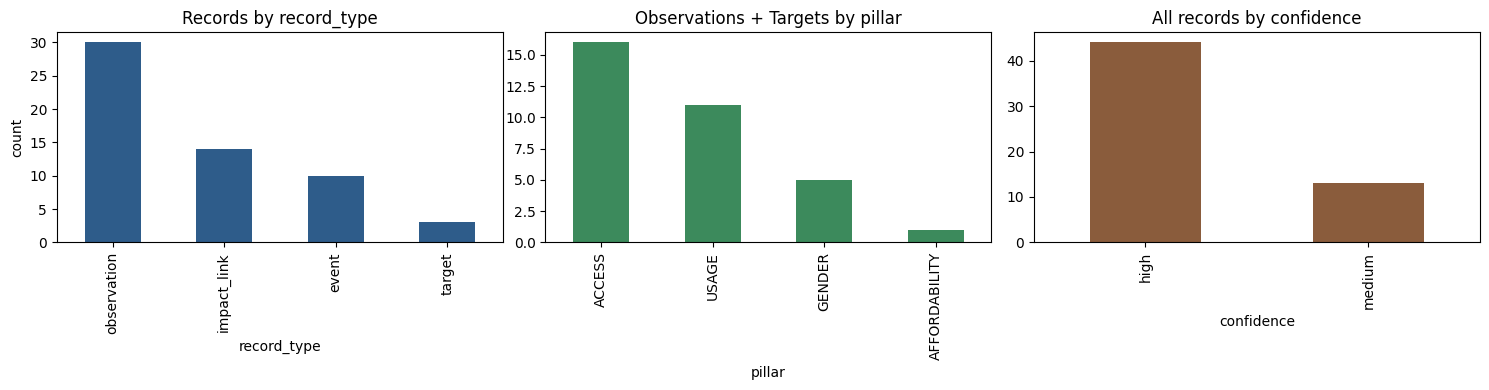

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['record_type'].value_counts().plot(kind='bar', ax=axes[0], color='#2E5C8A')
axes[0].set_title('Records by record_type')
axes[0].set_ylabel('count')

obs_targets['pillar'].value_counts().plot(kind='bar', ax=axes[1], color='#3C8A5C')
axes[1].set_title('Observations + Targets by pillar')

df['confidence'].value_counts().plot(kind='bar', ax=axes[2], color='#8A5C3C')
axes[2].set_title('All records by confidence')

plt.tight_layout()
plt.savefig('../reports/figures/task1_schema_overview.png', dpi=150)
plt.show()

## 4. Temporal Range of Observations

In [8]:
obs = df[df['record_type'] == 'observation'].copy()
print("Observation date range:", obs['observation_date'].min().date(), "to", obs['observation_date'].max().date())
print()
print("Observations per year:")
print(obs['observation_date'].dt.year.value_counts().sort_index())

Observation date range: 2014-12-31 to 2025-12-31

Observations per year:
observation_date
2014     1
2017     1
2021     5
2023     1
2024    11
2025    11
Name: count, dtype: int64


**Gap identified:** the earliest Findex-derived Access observation is 2014, but Ethiopia's
first Global Findex round was actually 2011 (14% account ownership, per the assignment
brief). That 2011 baseline is *not* in the starter dataset — a clear enrichment
opportunity we act on in the next notebook.

## 5. Unique Indicators and Coverage

In [9]:
ind_coverage = (
    obs_targets.groupby(['indicator_code', 'indicator', 'pillar'])
    .agg(n_records=('record_id', 'count'),
         first_date=('observation_date', 'min'),
         last_date=('observation_date', 'max'))
    .reset_index()
    .sort_values(['pillar', 'indicator_code'])
)
ind_coverage

,indicator_code,indicator,pillar,n_records,first_date,last_date
0,ACC_4G_COV,4G Population Coverage,ACCESS,2,2023-06-30,2025-06-30
1,ACC_FAYDA,Fayda Digital ID Enrollment,ACCESS,4,2024-08-15,2028-12-31
2,ACC_MM_ACCOUNT,Mobile Money Account Rate,ACCESS,2,2021-12-31,2024-11-29
3,ACC_MOBILE_PEN,Mobile Subscription Penetration,ACCESS,1,2025-12-31,2025-12-31
4,ACC_OWNERSHIP,Account Ownership Rate,ACCESS,7,2014-12-31,2025-12-31
5,AFF_DATA_INCOME,Data Affordability Index,AFFORDABILITY,1,2024-12-31,2024-12-31
6,GEN_GAP_ACC,Account Ownership Gender Gap,GENDER,2,2021-12-31,2024-11-29
7,GEN_GAP_MOBILE,Mobile Phone Gender Gap,GENDER,1,2024-12-31,2024-12-31
8,GEN_MM_SHARE,Female Mobile Money Account Share,GENDER,2,2024-12-31,2030-12-31
9,USG_ACTIVE_RATE,Mobile Money Activity Rate,USAGE,1,2024-12-31,2024-12-31


**Sparse coverage flags:** several indicators (`AFF_DATA_INCOME`, `GEN_MM_SHARE`,
`GEN_GAP_MOBILE`) have only 1–2 data points and no other pillar (`QUALITY`, `DEPTH`,
`TRUST`) has *any* observation yet. This directly limits which pillars we can model in
Task 3/4 without enrichment.

## 6. Cataloged Events and Their Dates

In [10]:
events_view = events[['record_id','category','indicator','observation_date','source_type','confidence']].sort_values('observation_date')
events_view

,record_id,category,indicator,observation_date,source_type,confidence
33,EVT_0001,product_launch,Telebirr Launch,2021-05-17,operator,high
41,EVT_0009,policy,NFIS-II Strategy Launch,2021-09-01,regulator,high
34,EVT_0002,market_entry,Safaricom Ethiopia Commercial Launch,2022-08-01,news,high
35,EVT_0003,product_launch,M-Pesa Ethiopia Launch,2023-08-01,operator,high
36,EVT_0004,infrastructure,Fayda Digital ID Program Rollout,2024-01-01,regulator,high
37,EVT_0005,policy,Foreign Exchange Liberalization,2024-07-29,regulator,high
38,EVT_0006,milestone,P2P Transaction Count Surpasses ATM,2024-10-01,operator,high
39,EVT_0007,partnership,M-Pesa EthSwitch Integration,2025-10-27,operator,high
42,EVT_0010,pricing,Safaricom Ethiopia Price Increase,2025-12-15,news,high
40,EVT_0008,infrastructure,EthioPay Instant Payment System Launch,2025-12-18,regulator,high


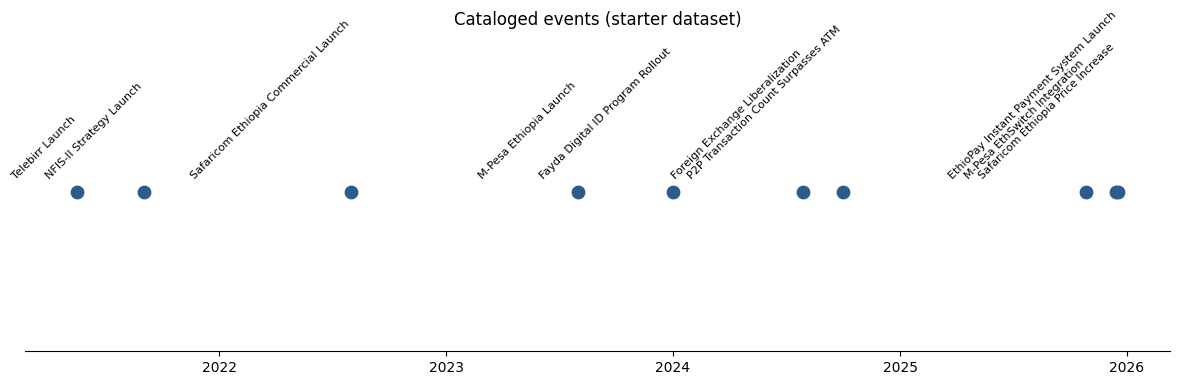

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(events_view['observation_date'], [1]*len(events_view), s=80, color='#2E5C8A', zorder=3)
for _, row in events_view.iterrows():
    ax.annotate(row['indicator'], (row['observation_date'], 1), rotation=45,
                ha='right', va='bottom', fontsize=8, xytext=(0, 8), textcoords='offset points')
ax.get_yaxis().set_visible(False)
ax.set_title('Cataloged events (starter dataset)')
for spine in ['top','right','left']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/task1_events_raw_timeline.png', dpi=150)
plt.show()

## 7. Existing `impact_link` Relationships — What They Capture

In [12]:
impacts = get_impact_links(df)
print(f"{len(impacts)} impact_link records, covering {impacts['parent_id'].nunique()} of {len(events)} events")
print()
print("Impact_links by pillar (of affected indicator):")
print(impacts['pillar'].value_counts())
print()
print("Impact_links by evidence_basis:")
print(impacts['evidence_basis'].value_counts())

14 impact_link records, covering 8 of 10 events

Impact_links by pillar (of affected indicator):
pillar
USAGE            6
ACCESS           4
AFFORDABILITY    3
GENDER           1
Name: count, dtype: int64

Impact_links by evidence_basis:
evidence_basis
literature     7
empirical      6
theoretical    1
Name: count, dtype: int64


In [13]:
events_no_impact = set(events['record_id']) - set(impacts['parent_id'])
print("Events with NO impact_link yet:", events_no_impact)
events[events['record_id'].isin(events_no_impact)][['record_id','indicator','category','observation_date']]

Events with NO impact_link yet: {'EVT_0006', 'EVT_0009'}


,record_id,indicator,category,observation_date
38,EVT_0006,P2P Transaction Count Surpasses ATM,milestone,2024-10-01
41,EVT_0009,NFIS-II Strategy Launch,policy,2021-09-01


**Gap identified:** `EVT_0006` (P2P/ATM crossover — a *milestone*, i.e. a consequence
rather than a driver) and `EVT_0009` (NFIS-II strategy launch) have no impact_links yet.
NFIS-II in particular is a major policy event (Ethiopia's national financial inclusion
strategy) that plausibly drives multiple pillars — an enrichment priority.

## 8. Summary of Exploration Findings

1. **Schema is fully compliant** — every categorical value in the starter dataset matches
   `reference_codes.csv`, and the "no pillar on events" design rule holds for all 10 events.
2. **Observations span 2014–2025** but are missing the 2011 Findex baseline.
3. **Pillar coverage is heavily skewed to ACCESS and USAGE** (as expected, since those are
   the forecasting targets); QUALITY, DEPTH, and TRUST have zero observations.
4. **10 events are cataloged**, 8 of which have at least one impact_link; NFIS-II policy
   launch and the P2P/ATM crossover milestone currently have none.
5. **14 impact_links** connect events to indicators, mixing `empirical` (Ethiopia-observed),
   `literature` (comparable-country), and `theoretical` evidence bases — useful to keep in
   mind when weighting them in Task 3.

These findings directly motivate the enrichment plan in `02.ipynb`.
